In [1]:
import pandas as pd
import json
from pathlib import Path

# Locate Walert data when running from either the repo root
# or the notebooks folder
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data" / "walert").exists():
    DATA_DIR = CURRENT_DIR / "data" / "walert"
elif (CURRENT_DIR.parent / "data" / "walert").exists():
    DATA_DIR = CURRENT_DIR.parent / "data" / "walert"
else:
    raise FileNotFoundError("Could not locate data/walert folder")

print("Using data from:", DATA_DIR)

# Load the main Walert test collection files
topics = pd.read_csv(DATA_DIR / "topics.csv")
collection = pd.read_csv(DATA_DIR / "collection.csv")
groundtruth = pd.read_csv(DATA_DIR / "groundtruth.csv")
gold_summaries = pd.read_csv(DATA_DIR / "gold_summaries.csv")

print("Topics shape:", topics.shape)
print("Collection shape:", collection.shape)
print("Ground truth shape:", groundtruth.shape)
print("Gold summaries shape:", gold_summaries.shape)

Using data from: /Users/seanrichards/Documents/University/DS Case Studies/WIL Project- Milestone 1/Case-Studies-WIL-Project/data/walert
Topics shape: (106, 4)
Collection shape: (120, 2)
Ground truth shape: (140, 5)
Gold summaries shape: (114, 4)


In [16]:
print("TOPICS")
display(topics.head())

print("\nCOLLECTION")
display(collection.head())

print("\nGROUND TRUTH")
display(groundtruth.head())

print("\nGOLD SUMMARIES")
display(gold_summaries.head())

TOPICS


,topic_id,topic,question_id,question
0,W01,what's the difference between CS and SE programs?,W01Q01,What sets apart CS programs from SE programs?
1,W01,what's the difference between CS and SE programs?,W01Q02,How do CS and SE programs differ from each other?
2,W01,what's the difference between CS and SE programs?,W01Q03,Can you explain the variances between CS and S...
3,W01,what's the difference between CS and SE programs?,W01Q04,what's the difference between CS and SE programs?
4,W02,What choice of electives available?,W02Q01,Can you describe the range of electives that a...



COLLECTION


,passage_id,passage
0,P01,The first two years of these two programs are ...
1,P02,"In the initial two years, the Software Enginee..."
2,P03,The first two years of both Software Engineeri...
3,P04,The Software Engineering and Computer Science ...
4,P05,The initial two years in both Software Enginee...



GROUND TRUTH


,topic_id,topic,passage_id,passage,relevance_judgment
0,W01,what's the difference between CS and SE programs?,P01,The first two years of these two programs are ...,2
1,W01,what's the difference between CS and SE programs?,P02,"In the initial two years, the Software Enginee...",2
2,W01,what's the difference between CS and SE programs?,P03,The first two years of both Software Engineeri...,2
3,W01,what's the difference between CS and SE programs?,P04,The Software Engineering and Computer Science ...,2
4,W01,what's the difference between CS and SE programs?,P05,The initial two years in both Software Enginee...,2



GOLD SUMMARIES


,question_id,summary_id,summary,passage_id
0,W21Q01,S21,You'll receive credit for only 75% of the cour...,P61
1,W21Q01,S21,You'll receive credit for only 75% of the cour...,P55
2,W21Q01,S21,You'll receive credit for only 75% of the cour...,P114
3,W22Q01,S22,"At RMIT, we organize various activities to hel...",P37
4,W23Q01,S23,Only SE students have to participate in an ind...,P01


In [17]:
# Inspect one complete Walert topic
example_topic = "W01"

print("QUESTIONS")
display(
    topics[topics["topic_id"] == example_topic][
        ["question_id", "question"]
    ]
)

print("\nRELEVANT PASSAGES")
display(
    groundtruth[groundtruth["topic_id"] == example_topic][
        ["passage_id", "passage", "relevance_judgment"]
    ]
)

QUESTIONS


,question_id,question
0,W01Q01,What sets apart CS programs from SE programs?
1,W01Q02,How do CS and SE programs differ from each other?
2,W01Q03,Can you explain the variances between CS and S...
3,W01Q04,what's the difference between CS and SE programs?



RELEVANT PASSAGES


,passage_id,passage,relevance_judgment
0,P01,The first two years of these two programs are ...,2
1,P02,"In the initial two years, the Software Enginee...",2
2,P03,The first two years of both Software Engineeri...,2
3,P04,The Software Engineering and Computer Science ...,2
4,P05,The initial two years in both Software Enginee...,2
5,P06,Software Engineering and Computer Science prog...,2


In [18]:
#%pip install rank-bm25

In [19]:
from rank_bm25 import BM25Okapi
import re

# Simple tokenizer for BM25
def tokenize(text):
    return re.findall(r"\b\w+\b", str(text).lower())

# Tokenise each Walert knowledge-base passage
tokenized_corpus = [
    tokenize(passage)
    for passage in collection["passage"]
]

# Build BM25 index
bm25 = BM25Okapi(tokenized_corpus)

print(f"BM25 index created using {len(tokenized_corpus)} Walert passages.")

BM25 index created using 120 Walert passages.


In [20]:
# Test BM25 on one Walert question
test_question = topics.loc[0, "question"]

query_tokens = tokenize(test_question)
scores = bm25.get_scores(query_tokens)

top_indices = scores.argsort()[::-1][:5]

results = collection.iloc[top_indices].copy()
results["bm25_score"] = scores[top_indices]

print("Question:")
print(test_question)

display(results[["passage_id", "passage", "bm25_score"]])




Question:
What sets apart CS programs from SE programs?


,passage_id,passage,bm25_score
34,P35,"Yes, all programs, apart from the Data Science...",12.694825
66,P67,There is no direct answer. It is easy between ...,9.901375
0,P01,The first two years of these two programs are ...,7.171982
31,P32,"Indeed, with the exception of the Data Science...",5.811915
119,P120,Not really. What matters the most is how you p...,5.444918


In [21]:
# Ground-truth relevant passages for the topic of this question
test_topic = topics.loc[0, "topic_id"]

relevant_passages = set(
    groundtruth.loc[
        groundtruth["topic_id"] == test_topic,
        "passage_id"
    ]
)

results["relevant"] = results["passage_id"].isin(relevant_passages)

display(results[[
    "passage_id",
    "bm25_score",
    "relevant",
    "passage"
]])


,passage_id,bm25_score,relevant,passage
34,P35,12.694825,False,"Yes, all programs, apart from the Data Science..."
66,P67,9.901375,False,There is no direct answer. It is easy between ...
0,P01,7.171982,True,The first two years of these two programs are ...
31,P32,5.811915,False,"Indeed, with the exception of the Data Science..."
119,P120,5.444918,False,Not really. What matters the most is how you p...


In [22]:
import numpy as np

def dcg_at_k(relevances, k):
    relevances = np.asarray(relevances)[:k]
    if relevances.size == 0:
        return 0.0
    
    discounts = np.log2(np.arange(2, relevances.size + 2))
    gains = (2 ** relevances - 1) / discounts
    return gains.sum()


def ndcg_at_k(retrieved_ids, topic_id, k=5):
    topic_gt = groundtruth[groundtruth["topic_id"] == topic_id]

    relevance_lookup = dict(
        zip(topic_gt["passage_id"], topic_gt["relevance_judgment"])
    )

    retrieved_relevances = [
        relevance_lookup.get(pid, 0)
        for pid in retrieved_ids[:k]
    ]

    ideal_relevances = sorted(
        topic_gt["relevance_judgment"].tolist(),
        reverse=True
    )[:k]

    dcg = dcg_at_k(retrieved_relevances, k)
    idcg = dcg_at_k(ideal_relevances, k)

    return dcg / idcg if idcg > 0 else np.nan

In [23]:
evaluation_results = []

for _, row in topics.iterrows():
    question_id = row["question_id"]
    topic_id = row["topic_id"]
    question = row["question"]

    query_tokens = tokenize(question)
    scores = bm25.get_scores(query_tokens)

    top_indices = scores.argsort()[::-1][:5]
    retrieved_ids = collection.iloc[top_indices]["passage_id"].tolist()

    ndcg5 = ndcg_at_k(
        retrieved_ids=retrieved_ids,
        topic_id=topic_id,
        k=5
    )

    evaluation_results.append({
        "question_id": question_id,
        "topic_id": topic_id,
        "question": question,
        "ndcg@5": ndcg5
    })

evaluation_df = pd.DataFrame(evaluation_results)

print("Questions evaluated:", len(evaluation_df))
print("Mean NDCG@5:", round(evaluation_df["ndcg@5"].mean(), 4))

display(evaluation_df.head())

Questions evaluated: 106
Mean NDCG@5: 0.4302


,question_id,topic_id,question,ndcg@5
0,W01Q01,W01,What sets apart CS programs from SE programs?,0.169580
1,W01Q02,W01,How do CS and SE programs differ from each other?,0.339160
2,W01Q03,W01,Can you explain the variances between CS and S...,0.146068
3,W01Q04,W01,what's the difference between CS and SE programs?,0.213986
4,W02Q01,W02,Can you describe the range of electives that a...,0.699215


In [24]:
evaluation_results = []

for _, row in topics.iterrows():
    question_id = row["question_id"]
    topic_id = row["topic_id"]
    question = row["question"]

    query_tokens = tokenize(question)
    scores = bm25.get_scores(query_tokens)

    top_indices = scores.argsort()[::-1][:5]
    retrieved_ids = collection.iloc[top_indices]["passage_id"].tolist()

    evaluation_results.append({
        "question_id": question_id,
        "topic_id": topic_id,
        "question": question,
        "ndcg@1": ndcg_at_k(retrieved_ids, topic_id, k=1),
        "ndcg@3": ndcg_at_k(retrieved_ids, topic_id, k=3),
        "ndcg@5": ndcg_at_k(retrieved_ids, topic_id, k=5)
    })

evaluation_df = pd.DataFrame(evaluation_results)

print("Questions evaluated:", len(evaluation_df))
print("Mean NDCG@1:", round(evaluation_df["ndcg@1"].mean(), 4))
print("Mean NDCG@3:", round(evaluation_df["ndcg@3"].mean(), 4))
print("Mean NDCG@5:", round(evaluation_df["ndcg@5"].mean(), 4))


Questions evaluated: 106
Mean NDCG@1: 0.5104
Mean NDCG@3: 0.4556
Mean NDCG@5: 0.4302


In [25]:
# Match Walert's original evaluation groups
known_topics = [f"W{i:02d}" for i in range(1, 21)] + ["W39"]
inferred_topics = [f"W{i:02d}" for i in range(21, 33)]

known_results = evaluation_df[
    evaluation_df["topic_id"].isin(known_topics)
]

inferred_results = evaluation_df[
    evaluation_df["topic_id"].isin(inferred_topics)
]

print("KNOWN QUESTIONS:", len(known_results))
print("NDCG@1:", round(known_results["ndcg@1"].mean(), 4))
print("NDCG@3:", round(known_results["ndcg@3"].mean(), 4))
print("NDCG@5:", round(known_results["ndcg@5"].mean(), 4))

print("\nINFERRED QUESTIONS:", len(inferred_results))
print("NDCG@1:", round(inferred_results["ndcg@1"].mean(), 4))
print("NDCG@3:", round(inferred_results["ndcg@3"].mean(), 4))
print("NDCG@5:", round(inferred_results["ndcg@5"].mean(), 4))

KNOWN QUESTIONS: 84
NDCG@1: 0.5714
NDCG@3: 0.5078
NDCG@5: 0.4718

INFERRED QUESTIONS: 12
NDCG@1: 0.0833
NDCG@3: 0.0902
NDCG@5: 0.1393


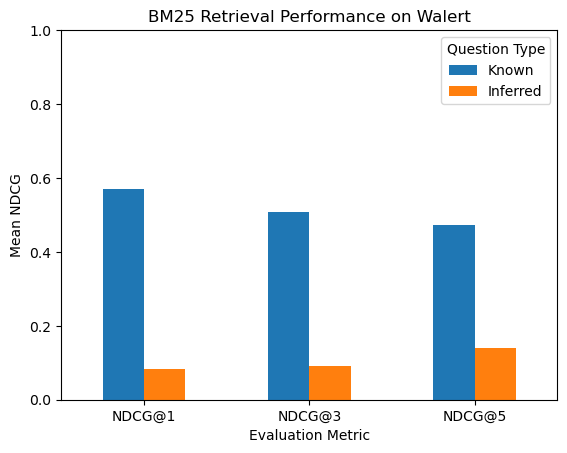

In [26]:
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Known": [
        known_results["ndcg@1"].mean(),
        known_results["ndcg@3"].mean(),
        known_results["ndcg@5"].mean()
    ],
    "Inferred": [
        inferred_results["ndcg@1"].mean(),
        inferred_results["ndcg@3"].mean(),
        inferred_results["ndcg@5"].mean()
    ]
}, index=["NDCG@1", "NDCG@3", "NDCG@5"])

comparison.plot(kind="bar")

plt.title("BM25 Retrieval Performance on Walert")
plt.ylabel("Mean NDCG")
plt.xlabel("Evaluation Metric")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Question Type")
plt.show()

### Progress so far

To start reproducing the Walert approach, we first cloned the original Walert GitHub repository and reviewed the structure of the `quantitative_eval` folder. The original reproduction environment was built around older versions of Python, Pyserini and Faiss, so we initially tried to recreate that environment using Python 3.9.

This led to several compatibility issues on the current Mac environment, particularly around Faiss, MKL and Pyserini dependencies. Rather than spending more time forcing the older stack to run, we kept the original Walert data and evaluation structure but reproduced the same BM25 retrieval approach using a current lightweight implementation.

We then loaded the original Walert evaluation files:

- `topics.csv` – 106 test questions, including multiple paraphrased versions of the same topic
- `collection.csv` – 120 knowledge-base passages
- `groundtruth.csv` – the known relevant passages and relevance scores for each topic
- `gold_summaries.csv` – expected summaries for questions that require information from multiple passages

This helped us understand how the Walert test collection is structured and how each question links back to one or more relevant passages.

We then created a BM25 index across all 120 Walert passages using the `rank-bm25` library. A first test question, **“What sets apart CS programs from SE programs?”**, showed that BM25 was able to retrieve one relevant passage, but ranked two unrelated passages above it. This gave us a useful first example of why retrieval needs to be evaluated rather than just checking whether the system returns an answer.

To quantitatively reproduce the Walert retrieval evaluation, we calculated **NDCG@1, NDCG@3 and NDCG@5** across the test questions. We then followed the Walert evaluation structure by separating the questions into **Known** and **Inferred** groups.

| Question Type | NDCG@1 | NDCG@3 | NDCG@5 |
|---|---:|---:|---:|
| Known | 0.5714 | 0.5078 | 0.4718 |
| Inferred | 0.0833 | 0.0902 | 0.1393 |

The results show a clear difference between the two question types. BM25 performs much better when the answer is directly represented in the knowledge base, while it performs poorly when the question requires information to be combined or inferred from multiple passages. We also created a comparison chart to make this difference easier to see across the three NDCG cut-offs.

This gives us an initial reproduction of the **retrieval and evaluation component of the Walert RAG approach**, which directly supports the Milestone 1 requirement to provide preliminary Walert reproduction results.

The next step is to extend this into a basic end-to-end RAG pipeline by passing the retrieved Walert passages into an LLM and then evaluating the generated answers.

In [27]:
import requests

In [28]:
# Use the first Walert question
test_question = topics.loc[0, "question"]

# Retrieve top 3 passages with BM25
query_tokens = tokenize(test_question)
scores = bm25.get_scores(query_tokens)
top_indices = scores.argsort()[::-1][:3]

top_passages = collection.iloc[top_indices]["passage"].tolist()

context = "\n\n".join(
    [f"Passage {i+1}: {p}" for i, p in enumerate(top_passages)]
)

prompt = f"""
You are answering a question using retrieved passages from a knowledge base.

Follow these steps:
1. Identify which passage is most directly relevant to the question.
2. Ignore passages that are about a different topic.
3. Answer only using the relevant passage.
4. If no passage contains enough information, respond:
"I don't have enough information to answer this question."

Question:
{test_question}

Passages:
{context}

Answer the question directly in 2-3 sentences.
"""

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "llama3.2:3b",
        #"model": "llama3.1:8b",
        "prompt": prompt,
        "stream": False
    }
)

answer = response.json()["response"]

print("QUESTION:")
print(test_question)

print("\nRETRIEVED PASSAGES:")
for i, passage in enumerate(top_passages, 1):
    print(f"\nPassage {i}:")
    print(passage)

print("\nGENERATED ANSWER:")
print(answer)

QUESTION:
What sets apart CS programs from SE programs?

RETRIEVED PASSAGES:

Passage 1:
Yes, all programs, apart from the Data Science degree, have secured professional-level accreditation from ACS.

Passage 2:
There is no direct answer. It is easy between some programs, and not as easy between some programs. For example, within first and second year, it is easy to transfer between SE and CS programs. Also, if you go from SE or CS to IT, it is easy to transfer. However, going up, such as IT to CS, will require certain requirements and assessed on merit.

Passage 3:
The first two years of these two programs are near-identical. Then, in the third year of the SE degree, students spend a whole year (roughly 40 working weeks) in an industry placement. They work in a software firm engaging in all facets of software development process, from design to deployment. Final year (third in CS and fourth in SE) are slightly different, in that, SE students will do another large in-house project and 